In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

X,y = make_blobs(
    n_samples=200 , centers=3 , cluster_std= 1.5 , random_state=42
)
k = 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=k , random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 2, 2,
       1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 1, 1, 0, 0, 1, 0, 1, 0, 2, 0, 1, 2,
       1, 2, 2, 1, 2, 0, 1, 0, 1, 0, 0, 0, 1, 2, 0, 2, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 2, 0, 2, 2, 0, 2, 0, 0, 2, 2, 1, 1, 1, 1, 0,
       2, 1, 2, 0, 0, 0, 2, 1, 0, 2, 2, 0, 1, 1, 0, 1, 0, 2, 1, 2, 2, 1,
       2, 2, 0, 1, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 1, 2, 0, 0, 2, 0, 2, 1,
       0, 1, 1, 2, 2, 2, 0, 2, 0, 0, 1, 2, 2, 0, 2, 1, 1, 2, 0, 1, 2, 1,
       2, 1, 1, 0, 2, 2, 0, 2, 2, 1, 0, 2, 2, 0, 1, 2, 1, 0, 2, 1, 0, 2,
       0, 0, 0, 2, 0, 2, 1, 1, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 0, 1, 0, 0,
       2, 2], dtype=int32)

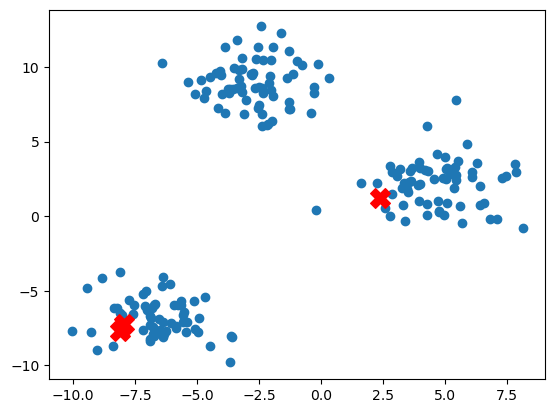

In [2]:
np.random.seed(42)
indices = np.random.choice(len(X) , k , replace=False)
centroids = X[indices]
plt.scatter(X[:,0] , X[:,1])
plt.scatter(centroids[:,0] , centroids[:,1] , c='red' , marker='X' , s= 200)
plt.show()

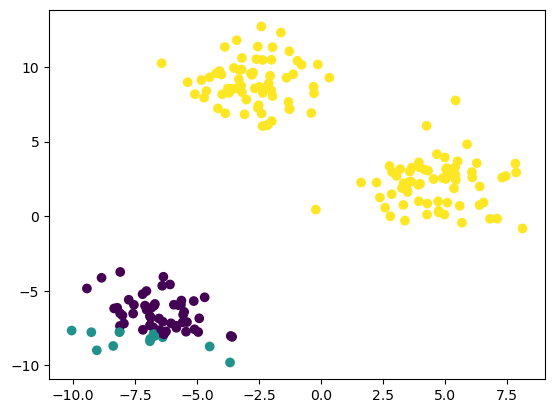

In [3]:
# step 2 각 점을 가장 가까운 중심에 할당
# 거리 계산 -> 가장 가까운 중심 선택
def assign_cluster(X,centroids):
    dist = np.linalg.norm(X[:,np.newaxis] - centroids , axis=2)
    return np.argmin(dist,axis=1)
labels = assign_cluster(X,centroids)
labels

plt.scatter(X[:,0] , X[:,1] , c = labels)
plt.show()

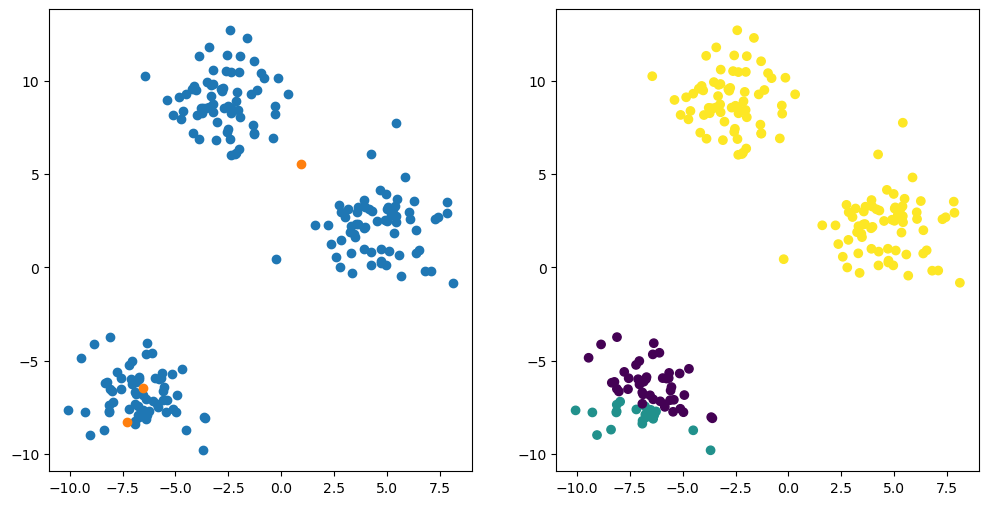

In [5]:
# step3 중심이동
# 각 그룹의 평균을 계산  --> 새로운 중심
def update_centroid(X,labels,k):
    return np.array(
        [ X[labels==i].mean(axis=0) for i in range(k) ]
    )

centroids = update_centroid(X,labels,k)   
# 1. 새로운중심점을 좌표에 업데이트
# 2. 새로운 중심점을 기준으로 label을 분리해서 시각화

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)  
plt.show() 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# 데이터 생성
X,y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)

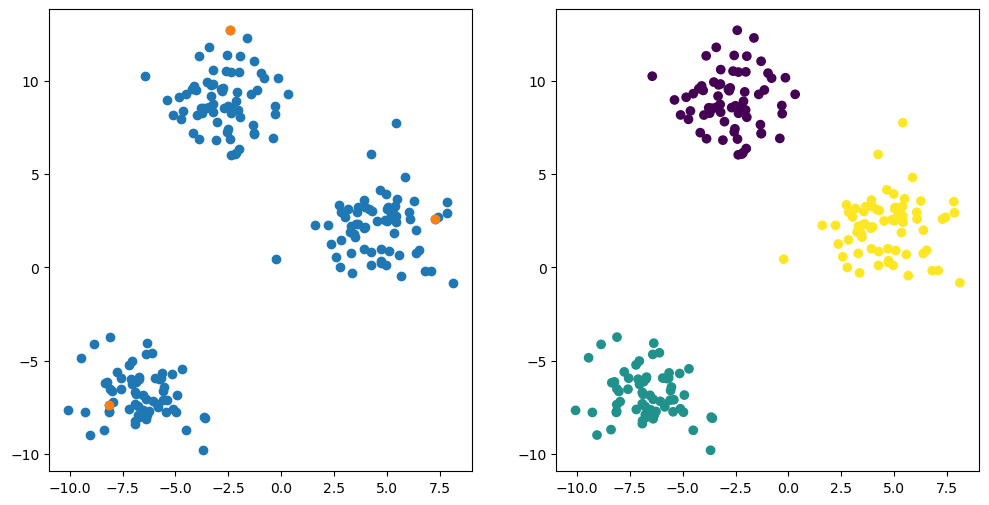

In [7]:
k = 3
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)

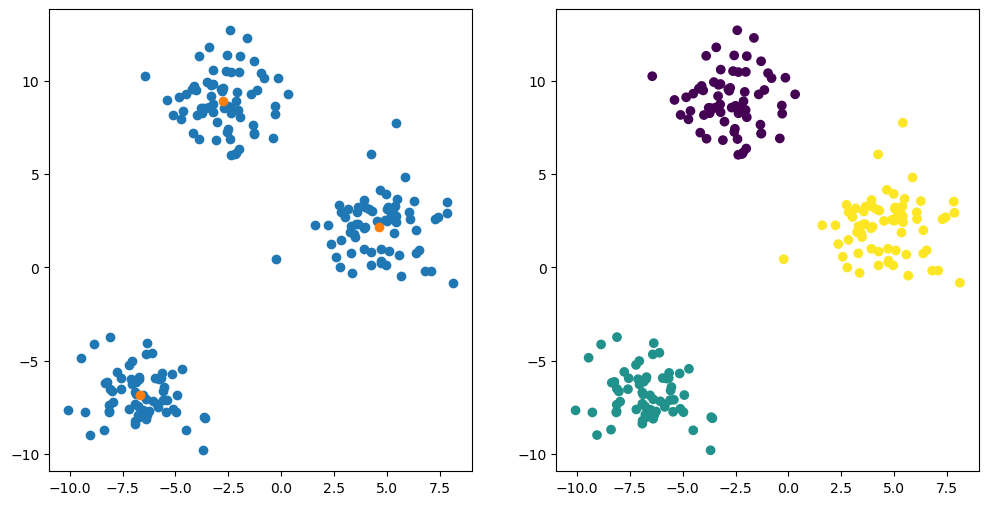

In [9]:
label = assign_cluster(X,centroids)
new_centroid = update_centroid(X,label,k)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].scatter(X[:,0], X[:,1])   
ax[0].scatter(centroids[:,0],centroids[:,1]) 

labels = assign_cluster(X,centroids)
ax[1].scatter(X[:,0], X[:,1],c=labels)  
plt.show() 

centroids = new_centroid

c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

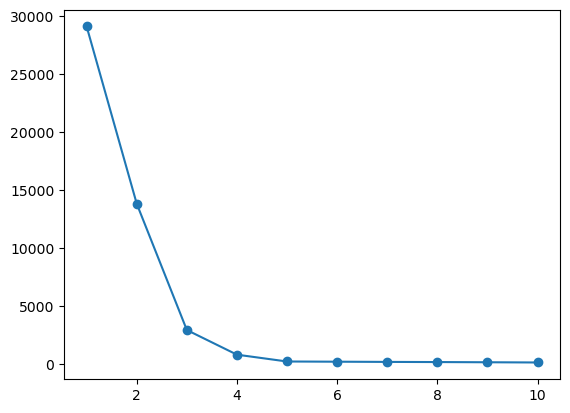

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# 데이터 생성
X,y = make_blobs(
    n_samples=500, centers=5, cluster_std=0.5, random_state=42
)
# 최적의 k개수 찾기  - Elbow Method (기본)
# k가 증가할수록 오차는 감소  WCSS (Within-Cluster-Sum of Square) : 각 점과 중심점과의 거리의 제곱의 합
# 어느순간 감소폭이 급격히 줄어든다 --> 그 지점
k_range = range(1,11)
wcss = []
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(k_range,wcss,'-o')    
plt.show()

In [13]:
# 실루엣 score  
# 같은클러스터끼리는 가깝고 다른 클러스터와는 멀어야 좋다   -1 ~ 1
from sklearn.metrics import silhouette_score
scores = []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    lables = kmeans.fit_predict(X)
    score = silhouette_score(X,lables)
    scores.append(score)
np.argmax(scores)+2

c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

np.int64(5)

c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: 

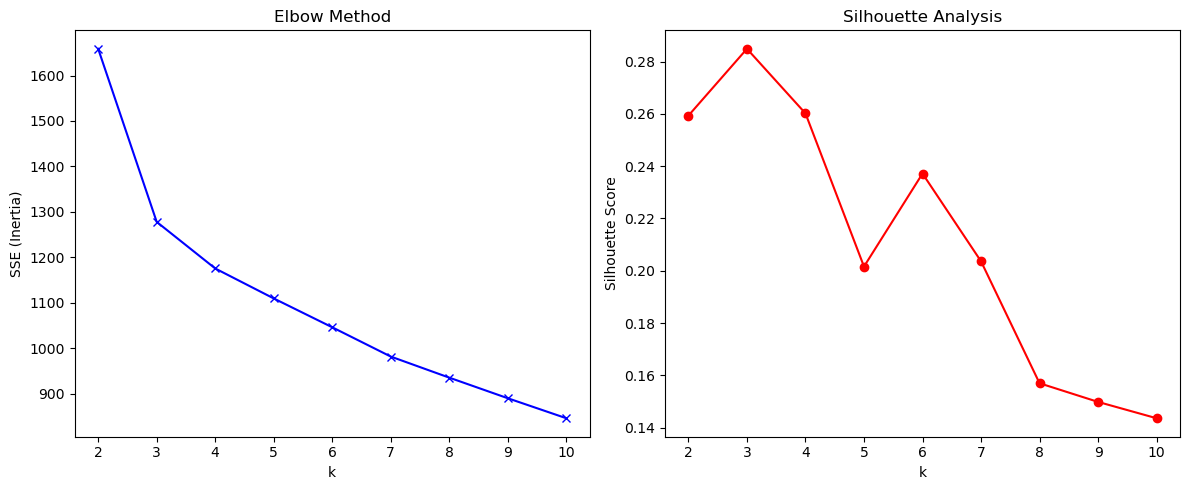

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. 데이터 로드 및 정답 제거
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# 2. 데이터 전처리 (K-Means는 거리 기반이므로 스케일링 필수)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 3. 최적의 K 찾기 (엘보우 & 실루엣)
sse = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)

    # 엘보우 기법을 위한 SSE 저장
    sse.append(kmeans.inertia_)
    
    # 실루엣 점수 저장
    score = silhouette_score(df_scaled, kmeans.labels_)
    sil_scores.append(score)

# 4. 시각화
plt.figure(figsize=(12, 5))
# 엘보우 그래프
plt.subplot(1, 2, 1)
plt.plot(k_range, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')

# 실루엣 그래프
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

In [ ]:
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target